In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [14]:


# 224×224 native
train_transforms = T.Compose([
    T.Resize((256, 256)),               # Resize to 256 (DenseNet standard)
    T.RandomCrop((224, 224)),           # Random crop to native size
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.1,
        hue=0.05
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

eval_transforms = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/train', transform=train_transforms)
val_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/valid', transform=eval_transforms)
test_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/test', transform=eval_transforms)



train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)




In [15]:
num_classes = len(train_dataset.classes)
print(f"Dataset sizes:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset.classes}")

Dataset sizes:
  Training samples: 1000
  Validation samples: 36
  Test samples: 38
Number of classes: 4
Classes: ['Angry', 'Other', 'Sad', 'happy']


##training
Trains the model for one complete pass through the training dataset, updating model weights via backpropagation.

###Parameters:
- `model`: The neural network to train
- `train_load`: DataLoader containing training batches
- `criterion`: Loss function (e.g., CrossEntropyLoss)
- `optimizer`: Optimization algorithm (e.g., Adam, SGD)
- `device`: Computation device (CPU or CUDA)
###Returns:
- `train_loss`: Average loss per batch for the epoch
- `train_acc`: Overall training accuracy percentage for the epoch
###Training Flow:
`Batch Input → Forward Pass → Loss Calculation → Backward Pass → Weight Update → Metrics Accumulation`

In [16]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100. * correct / total

#evaluation
Performs inference on a dataset, calculates performance metrics, and collects predictions for further analysis.

###Parameters:
- `model`: The neural network to evaluate
- `val_loader`: DataLoader containing validation/test batches
- `criterion`: Loss function (same as training)
- `device`: Computation device (CPU or CUDA)
###Returns:
- `val_loss`: Average loss per batch
- `val_acc`: Overall accuracy percentage
- `all_preds`: List of all predicted class indices
- `all_labels`: List of all ground truth labels


In [17]:
def evaluate(model, val_loader, criterion, device):
    model.eval() #Sets model to evaluation mode (disables dropout, uses running stats for batch norm)
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disables gradient computation to save memory and speed up inference
        #Iterates through batches in the DataLoader with progress visualization using `tqdm`.
        for inputs, labels in tqdm(val_loader, desc="Evaluating", leave=False):
            #Forward Pass Only
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # Metrics & Predictions Tracking
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc, all_preds, all_labels

In [18]:
def plot_confusion_matrix(cm, classes, model_name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [19]:
def train_and_evaluate_model(model_name, model, num_epochs=10, lr=0.001):
    print(f"\n{'='*60}")
    print(f"TRAINING AND EVALUATING: {model_name}")
    print(f"{'='*60}")

    model = model.to(device)

    class_counts = torch.zeros(num_classes)
    for _, label in train_dataset:
        class_counts[label] += 1

    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * num_classes  # Normalize
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    # Added Weight Decay (L2 Regularization) to the optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # --- REGULARIZATION: Cosine Annealing Scheduler ---
    # This smoothly transitions the LR over the course of training
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,        # First restart after 10 epochs
        T_mult=1,      # Keep period constant
        eta_min=1e-6   # Never drop below this
    )
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # 1. Training Phase
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # 2. Validation Phase
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        # 3. Step the Scheduler (called every epoch for Cosine Annealing)
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"  Current LR: {current_lr:.6f}")

        # Checkpointing (Best Model Saving) ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            # Save to disk for later use
            torch.save(best_model_state, f'best_{model_name.replace(" ", "_")}.pth')
            print(f"  --> Best model saved with Val Loss: {val_loss:.4f}")

    # Load the best model found during training for final evaluation
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n[INFO] Loaded the best model state (Val Loss: {best_val_loss:.4f}) for testing.")

    # --- FINAL EVALUATION ---
    print(f"\n{'='*60}")
    print(f"FINAL TEST EVALUATION - {model_name}")
    print(f"{'='*60}")

    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro')

    print(f"TEST Accuracy: {test_acc:.2f}%")
    print(f"TEST F1-Score: {f1:.4f}")

    # Classification report and Confusion Matrix
    print(f"\nTEST Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=test_dataset.classes))

    test_cm = confusion_matrix(test_labels, test_preds)
    plot_confusion_matrix(test_cm, test_dataset.classes, f"{model_name} (Test)")

    # Comparison and plotting
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='macro')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss Curves')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}%')
    ax2.set_title('Accuracy Curves')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'val_f1_score': val_f1,
        'test_f1_score': f1,
        'test_confusion_matrix': test_cm
    }

In [20]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super(VGGBlock, self).__init__()
        layers = []
        for i in range(num_convs):
            layers.append(nn.Conv2d(in_channels if i == 0 else out_channels,
                                   out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class VGG16(nn.Module):
    def __init__(self, num_classes=1000):
        super(VGG16, self).__init__()
        #**Feature Extractor (`self.features`):**
        #Five sequential VGG blocks:
        #1. 64 channels, 2 convs → 224×224 → 112×112
        #2.  128 channels, 2 convs → 112×112 → 56×56
        #3.  256 channels, 3 convs → 56×56 → 28×28
        #4.  512 channels, 3 convs → 28×28 → 14×14
        #5.  512 channels, 3 convs → 14×14 → 7×7
        self.features = nn.Sequential(
            VGGBlock(3, 64, 2),
            VGGBlock(64, 128, 2),
            VGGBlock(128, 256, 3),
            VGGBlock(256, 512, 3),
            VGGBlock(512, 512, 3)
        )
        #Adaptive Pooling:
        #nn.AdaptiveAvgPool2d((7, 7)): Ensures output is 7×7 regardless of input size
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        #Classifier (self.classifier): Three fully-connected layers:
        #512×7×7 → 4096 (with ReLU and 50% Dropout)
        #4096 → 4096 (with ReLU and 50% Dropout)
        #4096 → num_classes (output layer)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


TRAINING AND EVALUATING: VGG16

Epoch 1/20


  Train Loss: 8.0893 | Train Acc: 24.50%
  Val Loss: 2.8055 | Val Acc: 25.00%
  Current LR: 0.000976
  --> Best model saved with Val Loss: 2.8055

Epoch 2/20


  Train Loss: 1.4436 | Train Acc: 26.00%
  Val Loss: 1.3446 | Val Acc: 36.11%
  Current LR: 0.000905
  --> Best model saved with Val Loss: 1.3446

Epoch 3/20


  Train Loss: 1.4230 | Train Acc: 26.50%
  Val Loss: 1.3987 | Val Acc: 19.44%
  Current LR: 0.000794

Epoch 4/20


  Train Loss: 1.4071 | Train Acc: 26.10%
  Val Loss: 1.3709 | Val Acc: 27.78%
  Current LR: 0.000655

Epoch 5/20


...

  Train Loss: 1.3784 | Train Acc: 27.40%
  Val Loss: 1.3873 | Val Acc: 25.00%
  Current LR: 0.000207

Epoch 18/20


  Train Loss: 1.3758 | Train Acc: 27.30%
  Val Loss: 1.3968 | Val Acc: 25.00%
  Current LR: 0.000096

Epoch 19/20


  Train Loss: 1.3780 | Train Acc: 27.30%
  Val Loss: 1.3930 | Val Acc: 25.00%
  Current LR: 0.000025

Epoch 20/20


  Train Loss: 1.3722 | Train Acc: 28.90%
  Val Loss: 1.3924 | Val Acc: 25.00%
  Current LR: 0.001000

[INFO] Loaded the best model state (Val Loss: 1.3446) for testing.

FINAL TEST EVALUATION - VGG16


TEST Accuracy: 23.68%
TEST F1-Score: 0.1452

TEST Classification Report:
              precision    recall  f1-score   support

       Angry       0.25      0.80      0.38        10
       Other       0.25      0.17      0.20         6
         Sad       0.00      0.00      0.00        11
       happy       0.00      0.00      0.00        11

    accuracy                           0.24        38
   macro avg       0.12      0.24      0.15        38
weighted avg       0.11      0.24      0.13        38



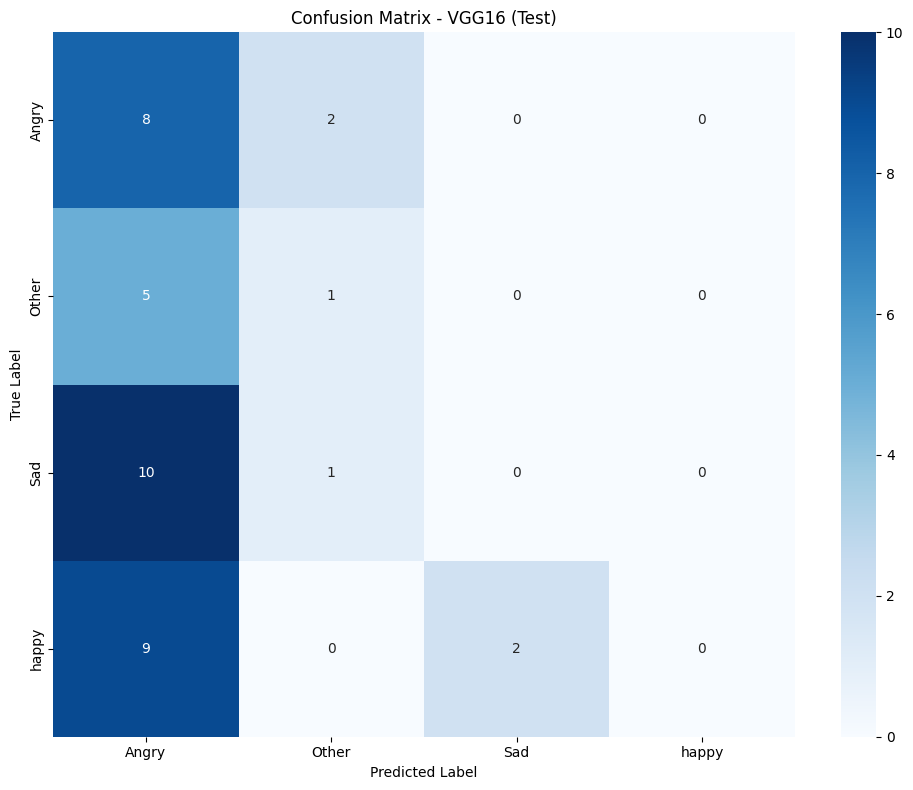

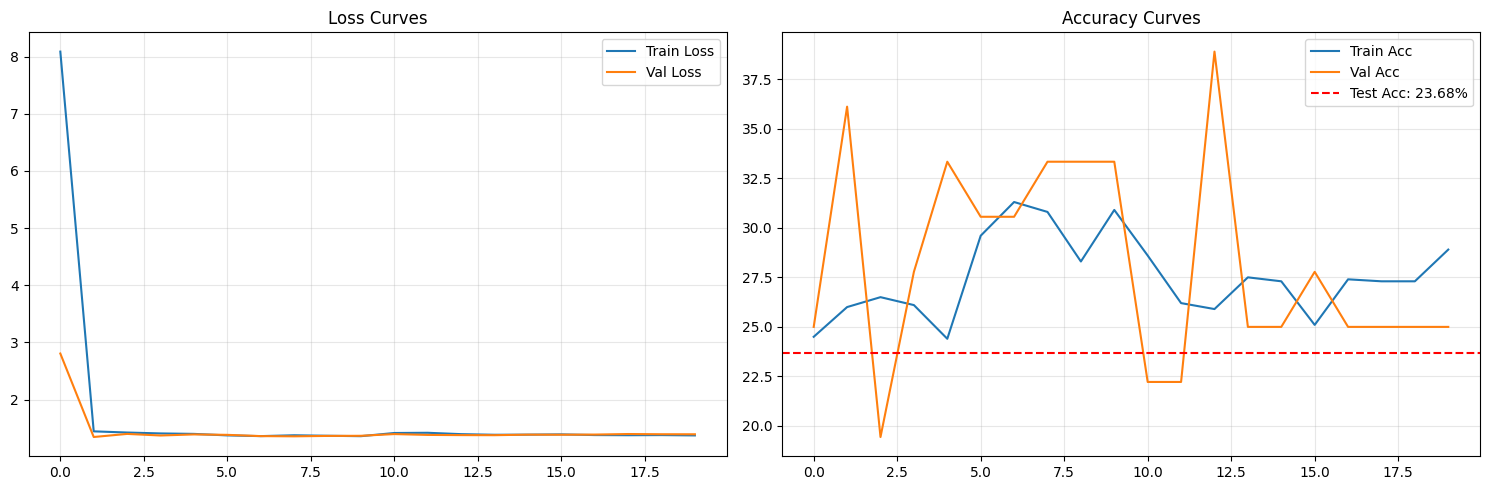

In [21]:
vgg_model = VGG16(num_classes=num_classes)
vgg_results = train_and_evaluate_model("VGG16", vgg_model, num_epochs=20, lr=0.001)

In [22]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        ### _make_layer Method
        #Factory method that creates each residual stage:
        #- First block may include downsampling
        #- Subsequent blocks maintain dimensions
        #- Properly manages channel expansion

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def ResNet18(num_classes=1000):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)


TRAINING AND EVALUATING: ResNet18

Epoch 1/20


  Train Loss: 1.5805 | Train Acc: 24.90%
  Val Loss: 1.6763 | Val Acc: 30.56%
  Current LR: 0.000976
  --> Best model saved with Val Loss: 1.6763

Epoch 2/20


  Train Loss: 1.3976 | Train Acc: 28.70%
  Val Loss: 1.4709 | Val Acc: 25.00%
  Current LR: 0.000905
  --> Best model saved with Val Loss: 1.4709

Epoch 3/20


  Train Loss: 1.4075 | Train Acc: 27.90%
  Val Loss: 1.4223 | Val Acc: 33.33%
  Current LR: 0.000794
  --> Best model saved with Val Loss: 1.4223

Epoch 4/20


  Train Loss: 1.3819 | Train Acc: 31.40%
  Val Loss: 1.4049 | Val Acc: 25.00%
  Current LR: 0.000655
  --> Best model saved with Val Loss: 1.4049

Epoch 5/20


...

  Train Loss: 1.3299 | Train Acc: 37.10%
  Val Loss: 1.2867 | Val Acc: 25.00%
  Current LR: 0.000207

Epoch 18/20


  Train Loss: 1.3008 | Train Acc: 39.50%
  Val Loss: 1.2641 | Val Acc: 33.33%
  Current LR: 0.000096

Epoch 19/20


  Train Loss: 1.2970 | Train Acc: 43.40%
  Val Loss: 1.2431 | Val Acc: 27.78%
  Current LR: 0.000025

Epoch 20/20


  Train Loss: 1.2744 | Train Acc: 42.20%
  Val Loss: 1.2257 | Val Acc: 30.56%
  Current LR: 0.001000

[INFO] Loaded the best model state (Val Loss: 1.1538) for testing.

FINAL TEST EVALUATION - ResNet18


TEST Accuracy: 39.47%
TEST F1-Score: 0.3939

TEST Classification Report:
              precision    recall  f1-score   support

       Angry       0.44      0.40      0.42        10
       Other       0.33      0.50      0.40         6
         Sad       0.33      0.27      0.30        11
       happy       0.45      0.45      0.45        11

    accuracy                           0.39        38
   macro avg       0.39      0.41      0.39        38
weighted avg       0.40      0.39      0.39        38



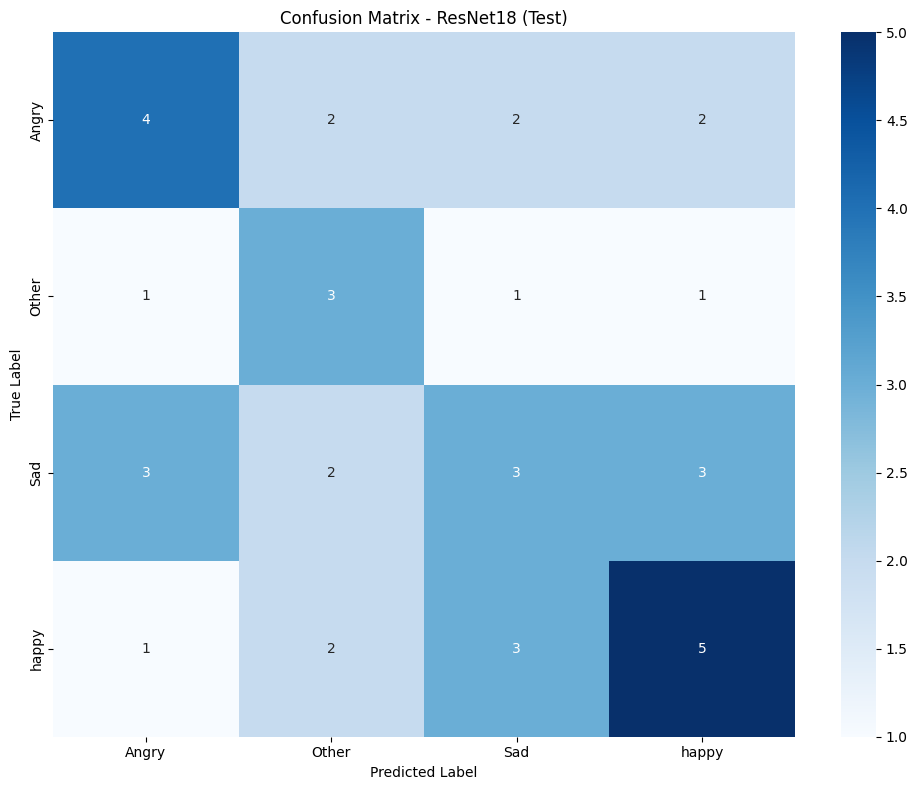

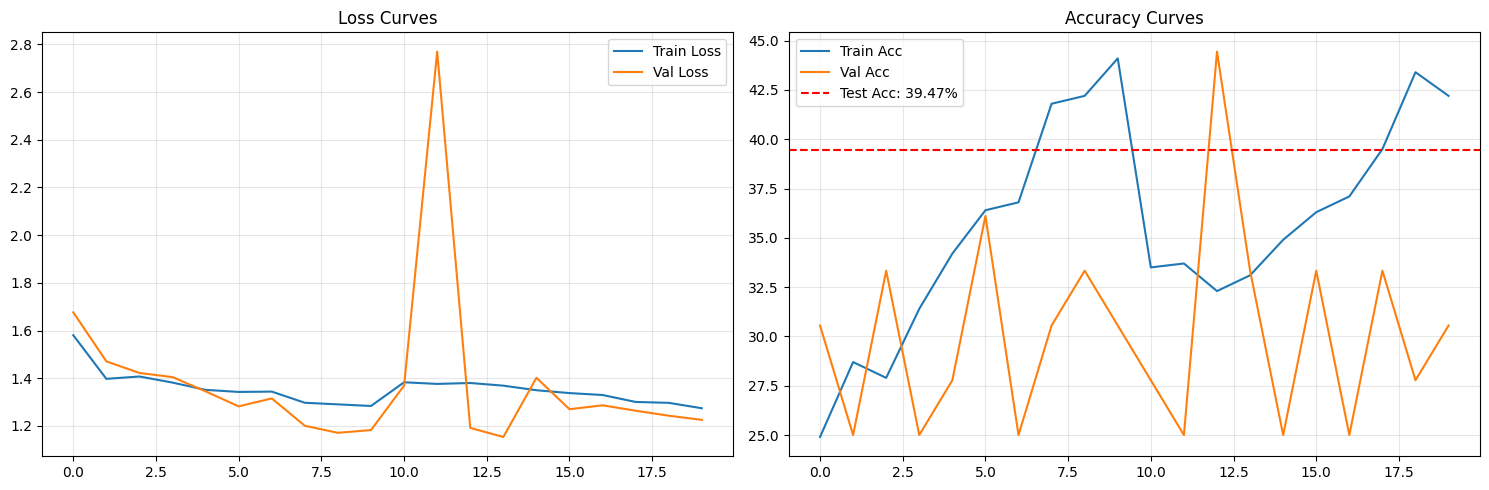

In [23]:
resnet_model = ResNet18(num_classes=num_classes)
resnet_results = train_and_evaluate_model("ResNet18", resnet_model, num_epochs=20, lr=0.001)

In [24]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                  stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                  stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class MobileNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(MobileNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, 1),
            DepthwiseSeparableConv(64, 128, 2),
            DepthwiseSeparableConv(128, 128, 1),
            DepthwiseSeparableConv(128, 256, 2),
            DepthwiseSeparableConv(256, 256, 1),
            DepthwiseSeparableConv(256, 512, 2),

            # 5x DepthwiseSeparableConv with stride 1
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),
            DepthwiseSeparableConv(512, 512, 1),

            DepthwiseSeparableConv(512, 1024, 2),
            DepthwiseSeparableConv(1024, 1024, 1),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


TRAINING AND EVALUATING: MobileNet

Epoch 1/20


  Train Loss: 1.4522 | Train Acc: 28.60%
  Val Loss: 3.0184 | Val Acc: 25.00%
  Current LR: 0.000976
  --> Best model saved with Val Loss: 3.0184

Epoch 2/20


  Train Loss: 1.4284 | Train Acc: 29.40%
  Val Loss: 1.9589 | Val Acc: 25.00%
  Current LR: 0.000905
  --> Best model saved with Val Loss: 1.9589

Epoch 3/20


  Train Loss: 1.3955 | Train Acc: 30.30%
  Val Loss: 1.6555 | Val Acc: 19.44%
  Current LR: 0.000794
  --> Best model saved with Val Loss: 1.6555

Epoch 4/20


  Train Loss: 1.3693 | Train Acc: 36.00%
  Val Loss: 1.5099 | Val Acc: 33.33%
  Current LR: 0.000655
  --> Best model saved with Val Loss: 1.5099

Epoch 5/20


...

  Train Loss: 1.2208 | Train Acc: 47.70%
  Val Loss: 1.2491 | Val Acc: 38.89%
  Current LR: 0.000207

Epoch 18/20


  Train Loss: 1.2181 | Train Acc: 49.00%
  Val Loss: 1.3601 | Val Acc: 36.11%
  Current LR: 0.000096

Epoch 19/20


  Train Loss: 1.1879 | Train Acc: 49.70%
  Val Loss: 1.3173 | Val Acc: 33.33%
  Current LR: 0.000025

Epoch 20/20


  Train Loss: 1.1832 | Train Acc: 50.70%
  Val Loss: 1.3876 | Val Acc: 36.11%
  Current LR: 0.001000

[INFO] Loaded the best model state (Val Loss: 1.2121) for testing.

FINAL TEST EVALUATION - MobileNet


TEST Accuracy: 28.95%
TEST F1-Score: 0.2805

TEST Classification Report:
              precision    recall  f1-score   support

       Angry       0.33      0.30      0.32        10
       Other       0.11      0.17      0.13         6
         Sad       0.29      0.36      0.32        11
       happy       0.50      0.27      0.35        11

    accuracy                           0.29        38
   macro avg       0.31      0.28      0.28        38
weighted avg       0.33      0.29      0.30        38



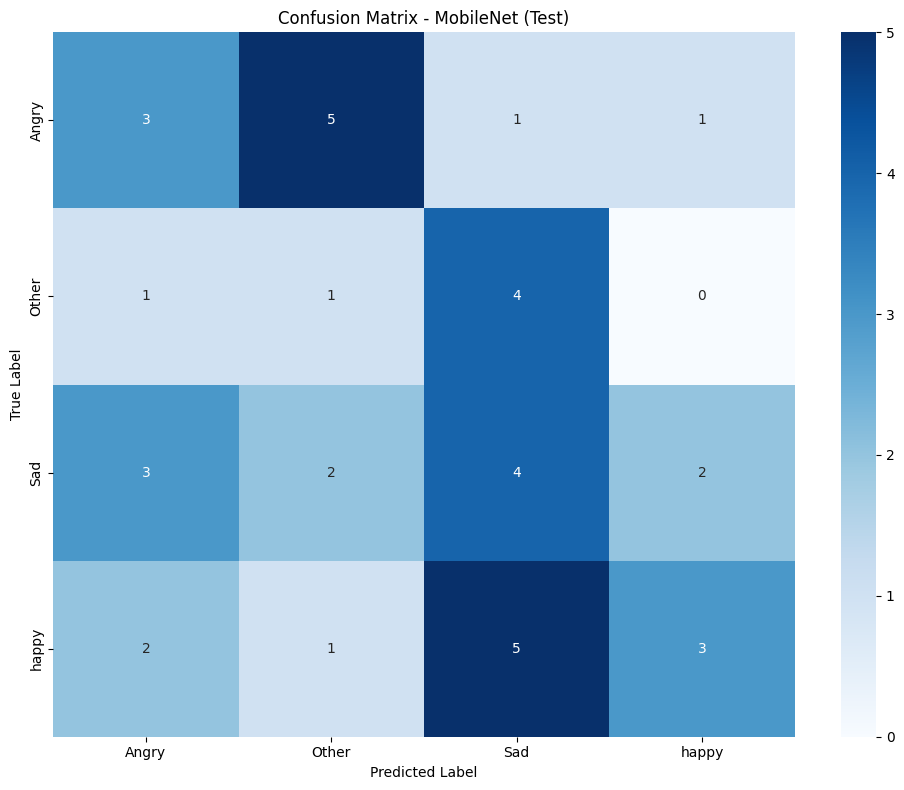

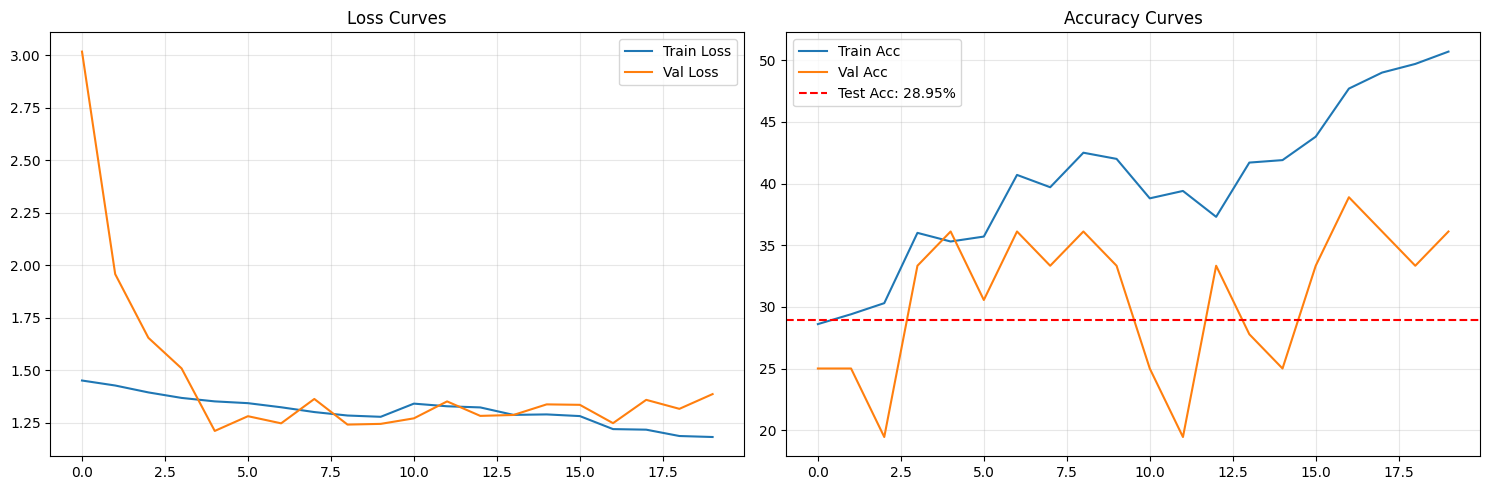

In [25]:
mobilenet_model = MobileNet(num_classes=num_classes)
mobilenet_results = train_and_evaluate_model("MobileNet", mobilenet_model, num_epochs=20, lr=0.001)